## EDA

Training:  {'pituitary': 1400, 'notumor': 1400, 'glioma': 1400, 'meningioma': 1400}
Testing:  {'pituitary': 400, 'notumor': 400, 'glioma': 400, 'meningioma': 400}


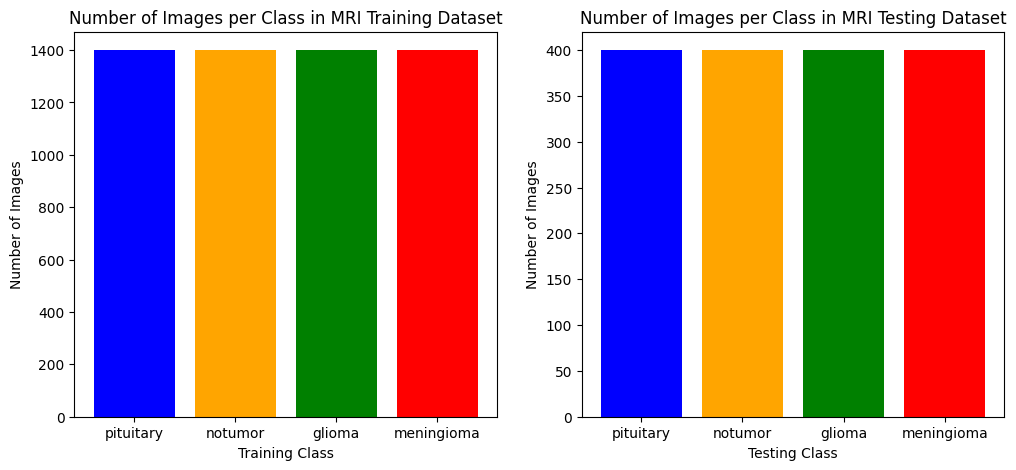

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np


train_dir = "MRI/Training"
test_dir = "MRI/Testing"


train_classes = os.listdir(train_dir)
train_class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in train_classes}
print("Training: ",train_class_counts)

test_classes = os.listdir(test_dir)
test_classes = [
    cls for cls in os.listdir(test_dir)
    if os.path.isdir(os.path.join(test_dir, cls))
]
test_class_counts = {
    cls: len(os.listdir(os.path.join(test_dir, cls)))
    for cls in test_classes
}
print("Testing: ",test_class_counts)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.bar(train_class_counts.keys(), train_class_counts.values(), color=['blue', 'orange', 'green', 'red'])
plt.title('Number of Images per Class in MRI Training Dataset')
plt.xlabel('Training Class')
plt.ylabel('Number of Images')


plt.subplot(1, 2, 2)
plt.bar(test_class_counts.keys(), test_class_counts.values(), color=['blue', 'orange', 'green', 'red'])
plt.title('Number of Images per Class in MRI Testing Dataset')
plt.xlabel('Testing Class')
plt.ylabel('Number of Images')

plt.show()


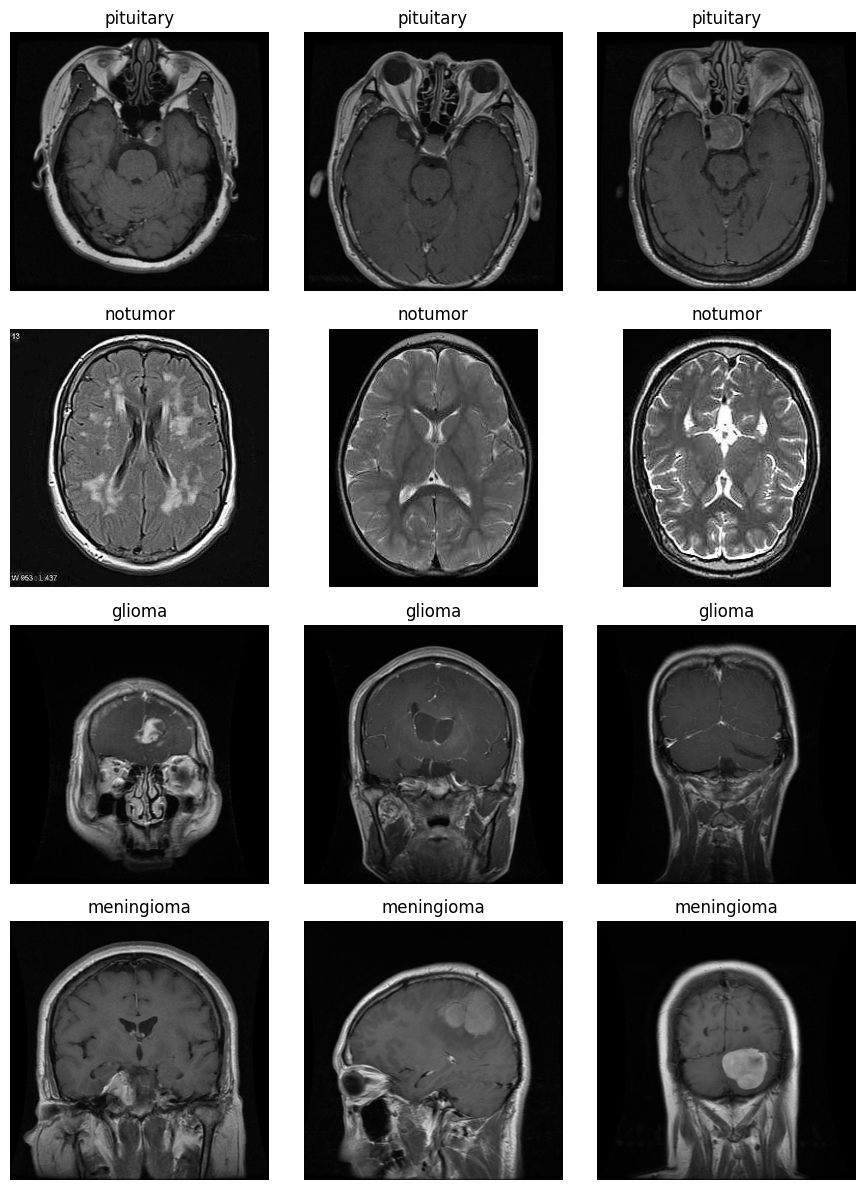

In [2]:
import random
from PIL import Image


list = os.listdir(train_dir)
def show_random_images(train_dir, num_per_class=3):
    
    classes = [
        cls for cls in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, cls))
            ]
    
    plt.figure(figsize=(num_per_class * 3, len(classes) * 3))
    
    plot_index = 1
    
    for cls in classes:
        class_path = os.path.join(train_dir, cls)
        images = os.listdir(class_path)
        
        selected = random.sample(images, min(len(images), num_per_class))
        
        for img_name in selected:
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            
            plt.subplot(len(classes), num_per_class, plot_index)
            plt.imshow(img, cmap='gray')
            plt.title(cls)
            plt.axis('off')
            
            plot_index += 1
    
    plt.tight_layout()
    plt.show()

show_random_images(train_dir, num_per_class=3)

In [3]:
sizes = []

for cls in train_classes:
    folder = os.path.join(train_dir, cls)
    for img_name in os.listdir(folder)[:50]:  # only check the first 50 images of each class
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)

print(set(sizes))

{(630, 630), (350, 350), (214, 236), (235, 277), (206, 244), (235, 228), (232, 217), (236, 300), (200, 252), (512, 512), (201, 251), (227, 300), (251, 273), (441, 427), (1338, 1304), (600, 600), (256, 256), (439, 512), (196, 257), (359, 449), (201, 250), (192, 192), (229, 214), (494, 600), (150, 198), (755, 824), (468, 444), (227, 262), (236, 280), (225, 225), (233, 226), (315, 341), (230, 282), (218, 231)}


In [4]:
img = Image.open(img_path)
print(img.mode)

arr = np.array(img)

print(arr.shape)  # (H, W, 3)
print((arr[:,:,0] == arr[:,:,1]).all())
print((arr[:,:,1] == arr[:,:,2]).all())

RGB
(512, 512, 3)
True
True


## Data Preprocessing

In [5]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([ 
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor()

])


train_dataset = datasets.ImageFolder(root='MRI/Training', transform=transform)
test_dataset = datasets.ImageFolder(root='MRI/Testing', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

images, labels = next(iter(train_loader))
print(images.shape)  # should be [32, 1, 224, 224]
print(labels.shape)  # should be [32]

torch.Size([32, 1, 224, 224])
torch.Size([32])


In [7]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, 4)  # 4 classes
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [8]:
import torch.optim as optim

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
for epoch in range(10):
    for images, labels in train_loader:
        
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.4903984069824219


KeyboardInterrupt: 